<a href="https://colab.research.google.com/github/TatkovDmitriy/-/blob/main/%D0%9F%D1%80%D0%BE%D0%B4%D0%B0%D0%B6%D0%B8_%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BE%D0%B2_%D0%9C%D0%A03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U -q PyDrive
!pip install -U -q PyDrive dateparser

# 📦 Загрузка библиотек для анализа данных

# Работа с таблицами и массивами
import pandas as pd
import numpy as np
import re
import dateparser
# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
plt.style.use('ggplot')  # безопасная альтернатива, встроенная в matplotlib
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_palette('Set2')

# Статистика и A/B-тесты
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Работа с датами
import datetime as dt
from google.colab import auth
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from oauth2client.client import GoogleCredentials


# Отображение и подавление предупреждений
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
print("библиотеки загружены")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 4.5 MB/s eta 0:00:00
библиотеки загружены


In [2]:
# 🔐 Аутентификация в Google Drive
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

print("✅ Аутентификация выполнена успешно")

✅ Аутентификация выполнена успешно


In [4]:
# ШАГ 1: Загрузка библиотеки для скачивания файлов
import gdown

print("📥 Загрузка данных из Google Drive...\n")

# ШАГ 2: Загрузка файла конфигуратора
print("1️⃣ Загрузка конфигуратора...")
url_configurator = 'https://drive.google.com/uc?id=1WndMhxdVlhJh5REjs-4rQysE6Le8S-l5'
gdown.download(url_configurator, 'configurator_data.csv', quiet=False)

# ШАГ 3: Загрузка файла сделок
print("\n2️⃣ Загрузка сделок...")
url_deals = 'https://drive.google.com/uc?id=1odBfka7wE_DdNgv2Yf0oddL7pPcX12xz'
gdown.download(url_deals, 'deals_data.csv', quiet=False)

print("\n✅ Файлы загружены успешно")

📥 Загрузка данных из Google Drive...

1️⃣ Загрузка конфигуратора...


Downloading...
From: https://drive.google.com/uc?id=1WndMhxdVlhJh5REjs-4rQysE6Le8S-l5
To: /content/configurator_data.csv
100%|██████████| 31.0k/31.0k [00:00<00:00, 43.7MB/s]



2️⃣ Загрузка сделок...


Downloading...
From: https://drive.google.com/uc?id=1odBfka7wE_DdNgv2Yf0oddL7pPcX12xz
To: /content/deals_data.csv
100%|██████████| 3.23M/3.23M [00:00<00:00, 207MB/s]


✅ Файлы загружены успешно


In [5]:
# 📊 Загрузка с правильным разделителем
df_configurator = pd.read_csv('configurator_data.csv', sep=';', encoding='utf-8-sig')

print(f"✅ Датасет конфигуратора загружен правильно")
print(f"Размерность: {df_configurator.shape[0]} строк × {df_configurator.shape[1]} колонок\n")

print("Колонки:")
for i, col in enumerate(df_configurator.columns, 1):
    print(f"  {i}. {col}")

print(f"\n📋 Первые 3 строки:")
display(df_configurator.head(3))

print(f"\n📊 Базовая информация:")
print(df_configurator.info())

✅ Датасет конфигуратора загружен правильно
Размерность: 210 строк × 4 колонок

Колонки:
  1. Артикул
  2. Наименование
  3. Дата загрузки в конфигуратор
  4. Проникновение в сделки

📋 Первые 3 строки:


,Артикул,Наименование,Дата загрузки в конфигуратор,Проникновение в сделки
0,90006073,Поверхность газовая чёрн стекло 3 комф Krona F...,00.00.2024,NaN
1,91503842,Фасад выдвижного ящика 797x125 мм Alternative ...,00.00.2024,NaN
2,91503843,Фасад выдвижного ящика 397x253 мм Alternative ...,00.00.2024,NaN



📊 Базовая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Артикул                       210 non-null    int64 
 1   Наименование                  210 non-null    object
 2   Дата загрузки в конфигуратор  210 non-null    object
 3   Проникновение в сделки        12 non-null     object
dtypes: int64(1), object(3)
memory usage: 6.7+ KB
None


In [6]:
# 📊 Загрузка с правильным разделителем
df_deals = pd.read_csv('deals_data.csv', sep=';', encoding='utf-8-sig')

print(f"✅ Датасет сделок загружен")
print(f"Размерность: {df_deals.shape[0]} строк × {df_deals.shape[1]} колонок\n")

print("Колонки:")
for i, col in enumerate(df_deals.columns, 1):
    print(f"  {i}. {col}")

print(f"\n📋 Первые 3 строки:")
display(df_deals.head(3))

print(f"\n📊 Базовая информация:")
print(df_deals.info())

✅ Датасет сделок загружен
Размерность: 12405 строк × 11 колонок

Колонки:
  1. Номер сделки
  2. Номер заказа
  3. Дата чека
  4. ТО
  5. Маржа товаров
  6. Шт.
  7. Отдел
  8. Подотдел
  9. Номер артикула
  10. Артикул
  11. Акция

📋 Первые 3 строки:


,Номер сделки,Номер заказа,Дата чека,ТО,Маржа товаров,Шт.,Отдел,Подотдел,Номер артикула,Артикул,Акция
0,000cbc50-54ff-4b06-bbae-41d424e254cf,MP7429594,06.06.2025,25275,NaN,1,7 САНТЕХНИКА,"715 УНИТАЗЫ,ИНСТАЛЛЯЦИИ",91425374.0,унитаз подвесной wellsee 182612001 безободковы...,NaN
1,00132a1b-169b-4b45-b29c-a573874c8f86,MP7804221,10.09.2025,3792,NaN,1,6 ПЛИТКА,651 УКЛАДКА И УХОД,92008112.0,ревизионный лючок шамрай lbn500x500 напольный ...,NaN
2,0034e2ed-9d4c-42cf-9de5-937af0d3376d,MP7563538,15.07.2025,76800,NaN,1,7 САНТЕХНИКА,730 ДУШЕВЫЕ КАБИНЫ,90766537.0,душевая кабина ceruttispa chika ct9154 900x900...,NaN



📊 Базовая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12405 entries, 0 to 12404
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Номер сделки    12405 non-null  object 
 1   Номер заказа    12405 non-null  object 
 2   Дата чека       12405 non-null  object 
 3   ТО              12405 non-null  int64  
 4   Маржа товаров   1 non-null      float64
 5   Шт.             12405 non-null  int64  
 6   Отдел           12395 non-null  object 
 7   Подотдел        12395 non-null  object 
 8   Номер артикула  12404 non-null  float64
 9   Артикул         12395 non-null  object 
 10  Акция           0 non-null      float64
dtypes: float64(3), int64(2), object(6)
memory usage: 1.0+ MB
None


In [7]:
# 🔍 АНАЛИЗ КАЧЕСТВА ДАННЫХ

print("="*60)
print("📊 ДАТАСЕТ 1: КОНФИГУРАТОР")
print("="*60)

print(f"\n1. Пропущенные значения:")
missing_conf = df_configurator.isnull().sum()
print(missing_conf)
print(f"\nПроцент пропусков:")
print((missing_conf / len(df_configurator) * 100).round(2))

print(f"\n2. Дубликаты по артикулу:")
duplicates_conf = df_configurator['Артикул'].duplicated().sum()
print(f"   Найдено дубликатов: {duplicates_conf}")

print(f"\n3. Уникальные значения в 'Проникновение в сделки':")
print(df_configurator['Проникновение в сделки'].value_counts(dropna=False))

print(f"\n4. Примеры дат:")
print(df_configurator['Дата загрузки в конфигуратор'].value_counts().head())

print("\n" + "="*60)
print("📊 ДАТАСЕТ 2: СДЕЛКИ")
print("="*60)

print(f"\n1. Пропущенные значения:")
missing_deals = df_deals.isnull().sum()
print(missing_deals[missing_deals > 0])

print(f"\n2. Дубликаты строк:")
duplicates_deals = df_deals.duplicated().sum()
print(f"   Найдено полных дубликатов: {duplicates_deals}")

print(f"\n3. Уникальные сделки:")
print(f"   Всего сделок: {df_deals['Номер сделки'].nunique()}")

print(f"\n4. Уникальные артикулы:")
print(f"   Всего артикулов: {df_deals['Номер артикула'].nunique()}")

print(f"\n5. Диапазон дат:")
print(f"   Мин дата: {df_deals['Дата чека'].min()}")
print(f"   Макс дата: {df_deals['Дата чека'].max()}")

📊 ДАТАСЕТ 1: КОНФИГУРАТОР

1. Пропущенные значения:
Артикул                           0
Наименование                      0
Дата загрузки в конфигуратор      0
Проникновение в сделки          198
dtype: int64

Процент пропусков:
Артикул                          0.00
Наименование                     0.00
Дата загрузки в конфигуратор     0.00
Проникновение в сделки          94.29
dtype: float64

2. Дубликаты по артикулу:
   Найдено дубликатов: 0

3. Уникальные значения в 'Проникновение в сделки':
Проникновение в сделки
NaN           198
не продаем     12
Name: count, dtype: int64

4. Примеры дат:
Дата загрузки в конфигуратор
00.00.2024    170
07.04.2025     32
26.05.2025      7
#ССЫЛКА!        1
Name: count, dtype: int64

📊 ДАТАСЕТ 2: СДЕЛКИ

1. Пропущенные значения:
Маржа товаров     12404
Отдел                10
Подотдел             10
Номер артикула        1
Артикул              10
Акция             12405
dtype: int64

2. Дубликаты строк:
   Найдено полных дубликатов: 0

3. Уникальные

In [8]:
# 🧹 ОЧИСТКА ДАТАСЕТА КОНФИГУРАТОР

print("🔧 Очистка датасета конфигуратора...\n")

# 1. Создаем копию для безопасности
df_conf_clean = df_configurator.copy()

# 2. Заполняем пропуски в "Проникновение в сделки"
# NaN = артикул еще не продавался
df_conf_clean['Проникновение в сделки'] = df_conf_clean['Проникновение в сделки'].fillna('нет данных')
print(f"✅ Заполнены пропуски в 'Проникновение в сделки'")

# 3. Чистим даты (удаляем некорректные)
print(f"\nДо очистки дат: {len(df_conf_clean)} строк")
df_conf_clean = df_conf_clean[df_conf_clean['Дата загрузки в конфигуратор'] != '#ССЫЛКА!']
print(f"После удаления '#ССЫЛКА!': {len(df_conf_clean)} строк")

# 4. Парсим даты в нормальный формат
def parse_date(date_str):
    if date_str == '00.00.2024':
        return None  # Неизвестная дата
    try:
        return pd.to_datetime(date_str, format='%d.%m.%Y', errors='coerce')
    except:
        return None

df_conf_clean['Дата загрузки'] = df_conf_clean['Дата загрузки в конфигуратор'].apply(parse_date)
print(f"✅ Даты преобразованы в datetime формат")

# 5. Создаем флаг "продается или нет"
df_conf_clean['Статус продажи'] = df_conf_clean['Проникновение в сделки'].apply(
    lambda x: 'не продается' if x == 'не продаем' else 'неизвестно' if x == 'нет данных' else 'продается'
)

print(f"\n📊 Итоговая статистика:")
print(df_conf_clean['Статус продажи'].value_counts())

print(f"\n✅ Очистка конфигуратора завершена")
print(f"Финальная размерность: {df_conf_clean.shape}")

display(df_conf_clean.head())

🔧 Очистка датасета конфигуратора...

✅ Заполнены пропуски в 'Проникновение в сделки'

До очистки дат: 210 строк
После удаления '#ССЫЛКА!': 209 строк
✅ Даты преобразованы в datetime формат

📊 Итоговая статистика:
Статус продажи
неизвестно      197
не продается     12
Name: count, dtype: int64

✅ Очистка конфигуратора завершена
Финальная размерность: (209, 6)


,Артикул,Наименование,Дата загрузки в конфигуратор,Проникновение в сделки,Дата загрузки,Статус продажи
0,90006073,Поверхность газовая чёрн стекло 3 комф Krona F...,00.00.2024,нет данных,NaT,неизвестно
1,91503842,Фасад выдвижного ящика 797x125 мм Alternative ...,00.00.2024,нет данных,NaT,неизвестно
2,91503843,Фасад выдвижного ящика 397x253 мм Alternative ...,00.00.2024,нет данных,NaT,неизвестно
3,91503865,Кухонный карниз 4x220 мм Alternative Бежевый г...,00.00.2024,нет данных,NaT,неизвестно
4,91503862,Фасад универсальный для кухонного шкафа 397x10...,00.00.2024,нет данных,NaT,неизвестно


In [9]:
# 🧹 ОЧИСТКА ДАТАСЕТА СДЕЛКИ

print("🔧 Очистка датасета сделок...\n")

# 1. Создаем копию
df_deals_clean = df_deals.copy()

print(f"Исходный размер: {df_deals_clean.shape}")

# 2. Удаляем строки без артикула (критично для анализа)
print(f"\nСтрок без артикула: {df_deals_clean['Номер артикула'].isnull().sum()}")
df_deals_clean = df_deals_clean.dropna(subset=['Номер артикула'])
print(f"После удаления: {len(df_deals_clean)} строк")

# 3. Преобразуем артикул в int (для объединения с конфигуратором)
df_deals_clean['Номер артикула'] = df_deals_clean['Номер артикула'].astype(int)
print(f"✅ Артикулы преобразованы в int")

# 4. Парсим даты
df_deals_clean['Дата чека'] = pd.to_datetime(df_deals_clean['Дата чека'], format='%d.%m.%Y', errors='coerce')
print(f"✅ Даты преобразованы в datetime")

# 5. Удаляем строки с некорректными датами
print(f"\nСтрок с некорректными датами: {df_deals_clean['Дата чека'].isnull().sum()}")
df_deals_clean = df_deals_clean.dropna(subset=['Дата чека'])
print(f"После удаления: {len(df_deals_clean)} строк")

# 6. Чистим колонку ТО (убираем пробелы)
df_deals_clean['ТО'] = df_deals_clean['ТО'].astype(str).str.strip()

# 7. Преобразуем Шт. в числовой формат
df_deals_clean['Шт.'] = pd.to_numeric(df_deals_clean['Шт.'], errors='coerce').fillna(1)
print(f"✅ Количество товаров преобразовано в числовой формат")

# 8. Добавляем временные метки
df_deals_clean['Год'] = df_deals_clean['Дата чека'].dt.year
df_deals_clean['Месяц'] = df_deals_clean['Дата чека'].dt.month
df_deals_clean['Неделя'] = df_deals_clean['Дата чека'].dt.isocalendar().week

print(f"\n📊 Итоговая статистика сделок:")
print(f"Период: {df_deals_clean['Дата чека'].min()} — {df_deals_clean['Дата чека'].max()}")
print(f"Уникальных сделок: {df_deals_clean['Номер сделки'].nunique()}")
print(f"Уникальных артикулов: {df_deals_clean['Номер артикула'].nunique()}")
print(f"Всего позиций: {len(df_deals_clean)}")

print(f"\n✅ Очистка сделок завершена")
print(f"Финальная размерность: {df_deals_clean.shape}")

display(df_deals_clean.head(3))

🔧 Очистка датасета сделок...

Исходный размер: (12405, 11)

Строк без артикула: 1
После удаления: 12404 строк
✅ Артикулы преобразованы в int
✅ Даты преобразованы в datetime

Строк с некорректными датами: 0
После удаления: 12404 строк
✅ Количество товаров преобразовано в числовой формат

📊 Итоговая статистика сделок:
Период: 2025-01-03 00:00:00 — 2025-09-30 00:00:00
Уникальных сделок: 6313
Уникальных артикулов: 8210
Всего позиций: 12404

✅ Очистка сделок завершена
Финальная размерность: (12404, 14)


,Номер сделки,Номер заказа,Дата чека,ТО,Маржа товаров,Шт.,Отдел,Подотдел,Номер артикула,Артикул,Акция,Год,Месяц,Неделя
0,000cbc50-54ff-4b06-bbae-41d424e254cf,MP7429594,2025-06-06,25275,NaN,1,7 САНТЕХНИКА,"715 УНИТАЗЫ,ИНСТАЛЛЯЦИИ",91425374,унитаз подвесной wellsee 182612001 безободковы...,NaN,2025,6,23
1,00132a1b-169b-4b45-b29c-a573874c8f86,MP7804221,2025-09-10,3792,NaN,1,6 ПЛИТКА,651 УКЛАДКА И УХОД,92008112,ревизионный лючок шамрай lbn500x500 напольный ...,NaN,2025,9,37
2,0034e2ed-9d4c-42cf-9de5-937af0d3376d,MP7563538,2025-07-15,76800,NaN,1,7 САНТЕХНИКА,730 ДУШЕВЫЕ КАБИНЫ,90766537,душевая кабина ceruttispa chika ct9154 900x900...,NaN,2025,7,29


In [10]:
# 📊 АНАЛИЗ ПРОДАЖ АРТИКУЛОВ ИЗ КОНФИГУРАТОРА

print("🔍 Создание аналитической таблицы продаж артикулов 3Р\n")

# 1. Фильтруем сделки - только артикулы из конфигуратора
artikuls_in_conf = df_conf_clean['Артикул'].unique()
df_sales_3p = df_deals_clean[df_deals_clean['Номер артикула'].isin(artikuls_in_conf)].copy()

print(f"✅ Отфильтровано сделок с артикулами из конфигуратора: {len(df_sales_3p)}")
print(f"   Уникальных артикулов 3Р в сделках: {df_sales_3p['Номер артикула'].nunique()}")

# 2. Преобразуем ТО (GMV) в числовой формат
df_sales_3p['GMV'] = pd.to_numeric(df_sales_3p['ТО'], errors='coerce')

print(f"\n   Строк с корректным GMV: {df_sales_3p['GMV'].notna().sum()}")
print(f"   Строк с пропусками GMV: {df_sales_3p['GMV'].isna().sum()}")

# 3. Агрегируем продажи по артикулам
sales_aggregated = df_sales_3p.groupby('Номер артикула').agg({
    'Шт.': 'sum',           # Количество проданных штук
    'GMV': 'sum',           # Суммарный GMV
    'Номер сделки': 'nunique'  # Количество сделок (для справки)
}).reset_index()

sales_aggregated.columns = ['Артикул', 'Количество_штук', 'Суммарный_GMV', 'Количество_сделок']

print(f"\n✅ Агрегация по артикулам завершена")
print(f"   Артикулов с продажами: {len(sales_aggregated)}")

# 4. Объединяем с конфигуратором для получения наименований
result_table = df_conf_clean[['Артикул', 'Наименование']].merge(
    sales_aggregated,
    on='Артикул',
    how='left'
)

# Заполняем нули для артикулов без продаж
result_table['Количество_штук'] = result_table['Количество_штук'].fillna(0).astype(int)
result_table['Суммарный_GMV'] = result_table['Суммарный_GMV'].fillna(0).round(2)
result_table['Количество_сделок'] = result_table['Количество_сделок'].fillna(0).astype(int)

# 5. Сортируем по GMV (от большего к меньшему)
result_table = result_table.sort_values('Суммарный_GMV', ascending=False).reset_index(drop=True)

print(f"\n✅ ИТОГОВАЯ ТАБЛИЦА СОЗДАНА")
print(f"   Всего артикулов в конфигураторе: {len(result_table)}")
print(f"   Из них с продажами: {(result_table['Суммарный_GMV'] > 0).sum()}")
print(f"   Без продаж: {(result_table['Суммарный_GMV'] == 0).sum()}")

print(f"\n📈 ТОП-10 артикулов по GMV:")
display(result_table.head(10))

print(f"\n📉 Артикулы БЕЗ продаж (первые 10):")
display(result_table[result_table['Суммарный_GMV'] == 0].head(10))

🔍 Создание аналитической таблицы продаж артикулов 3Р

✅ Отфильтровано сделок с артикулами из конфигуратора: 225
   Уникальных артикулов 3Р в сделках: 62

   Строк с корректным GMV: 225
   Строк с пропусками GMV: 0

✅ Агрегация по артикулам завершена
   Артикулов с продажами: 62

✅ ИТОГОВАЯ ТАБЛИЦА СОЗДАНА
   Всего артикулов в конфигураторе: 209
   Из них с продажами: 62
   Без продаж: 147

📈 ТОП-10 артикулов по GMV:


,Артикул,Наименование,Количество_штук,Суммарный_GMV,Количество_сделок
0,90778275,встраиваемый холодильник weissgauff wrki 178 v...,17,690381.0,17
1,90778276,встраиваемый холодильник weissgauff wrki 178 v...,11,509552.0,11
2,91903185,встраиваемый холодильник weissgauff 178 nfm 54...,7,416330.0,7
3,90017373,Духовой шкаф электрический Krona Breve 45 bl 4...,16,335238.0,16
4,90198859,Индукционная варочная панель Krona КА-00001447...,24,254225.0,24
5,90395059,Индукционная варочная панель Krona Forte 45 BL...,11,175868.0,11
6,93738658,посудомоечная машина weissgauff bdw 4543 d,6,173790.0,6
7,91388842,Индукционная варочная панель MAUNFELD CVI453BK,7,140350.0,7
8,90544057,Встраиваемая посудомоечная машина Krona Lumera...,4,125904.0,3
9,90006950,Индукционная варочная панель Krona OMBRA 45 BL...,5,76151.0,5



📉 Артикулы БЕЗ продаж (первые 10):


,Артикул,Наименование,Количество_штук,Суммарный_GMV,Количество_сделок
62,91503868,Фасад универсальный для кухонного шкафа 597x13...,0,0.0,0
63,91503846,Фальшпанель для кухонного шкафа 580x768 мм Alt...,0,0.0,0
64,91503863,Фасад универсальный для кухонного шкафа 597x16...,0,0.0,0
65,91503831,Фасад универсальный для кухонного шкафа 447x10...,0,0.0,0
66,91503813,Фасад выдвижного ящика 397x125 мм Alternative ...,0,0.0,0
67,91503841,Фасад выдвижного ящика 597x125 мм Alternative ...,0,0.0,0
68,91503859,Фасад универсальный для кухонного шкафа 597x10...,0,0.0,0
69,91503851,Фасад универсальный для кухонного шкафа 147x10...,0,0.0,0
70,91503849,Фасад выдвижного ящика 797x381 мм Alternative ...,0,0.0,0
71,91503845,Фасад выдвижного ящика 797x253 мм Alternative ...,0,0.0,0


In [11]:
# 📊 ОБЩИЕ ПОКАЗАТЕЛИ ПРОДАЖ АРТИКУЛОВ ИЗ КОНФИГУРАТОРА

print("="*60)
print("📈 ИТОГОВЫЕ МЕТРИКИ ПО АРТИКУЛАМ 3Р В КОНФИГУРАТОРЕ")
print("="*60)

# Общий GMV
total_gmv = result_table['Суммарный_GMV'].sum()
print(f"\n💰 Общий GMV артикулов из конфигуратора: {total_gmv:,.2f} ₽")

# Общее количество проданных штук
total_units = result_table['Количество_штук'].sum()
print(f"📦 Всего продано штук: {total_units:,}")

# Общее количество сделок
total_deals = result_table['Количество_сделок'].sum()
print(f"🤝 Всего сделок с артикулами 3Р: {total_deals:,}")

# Средний чек
avg_gmv_per_deal = total_gmv / total_deals if total_deals > 0 else 0
print(f"💳 Средний GMV на сделку: {avg_gmv_per_deal:,.2f} ₽")

# Средняя цена за штуку
avg_price_per_unit = total_gmv / total_units if total_units > 0 else 0
print(f"🏷️ Средняя цена за единицу товара: {avg_price_per_unit:,.2f} ₽")

print("\n" + "="*60)
print("📊 СТРУКТУРА АССОРТИМЕНТА")
print("="*60)

artikuls_with_sales = (result_table['Суммарный_GMV'] > 0).sum()
artikuls_no_sales = (result_table['Суммарный_GMV'] == 0).sum()
conversion_rate = (artikuls_with_sales / len(result_table)) * 100

print(f"\n📌 Всего артикулов в конфигураторе: {len(result_table)}")
print(f"   ✅ С продажами: {artikuls_with_sales} ({conversion_rate:.1f}%)")
print(f"   ❌ Без продаж: {artikuls_no_sales} ({100-conversion_rate:.1f}%)")

print("\n" + "="*60)

📈 ИТОГОВЫЕ МЕТРИКИ ПО АРТИКУЛАМ 3Р В КОНФИГУРАТОРЕ

💰 Общий GMV артикулов из конфигуратора: 3,586,675.00 ₽
📦 Всего продано штук: 273
🤝 Всего сделок с артикулами 3Р: 223
💳 Средний GMV на сделку: 16,083.74 ₽
🏷️ Средняя цена за единицу товара: 13,138.00 ₽

📊 СТРУКТУРА АССОРТИМЕНТА

📌 Всего артикулов в конфигураторе: 209
   ✅ С продажами: 62 (29.7%)
   ❌ Без продаж: 147 (70.3%)




📊 СТАТИСТИКА ПО ЧАСТОТЕ ПРОДАЖ:
Продано 1 раз: 28 артикулов (45.2%)
Продано 2 раз: 9 артикулов (14.5%)
Продано 3 раз: 7 артикулов (11.3%)
Продано 4 раз: 3 артикулов (4.8%)
Продано 5 раз: 4 артикулов (6.5%)
Продано 6 раз: 1 артикулов (1.6%)
Продано 7 раз: 3 артикулов (4.8%)
Продано 8 раз: 1 артикулов (1.6%)
Продано 10 раз: 1 артикулов (1.6%)
Продано 11 раз: 2 артикулов (3.2%)
Продано 16 раз: 1 артикулов (1.6%)
Продано 17 раз: 1 артикулов (1.6%)
Продано 24 раз: 1 артикулов (1.6%)


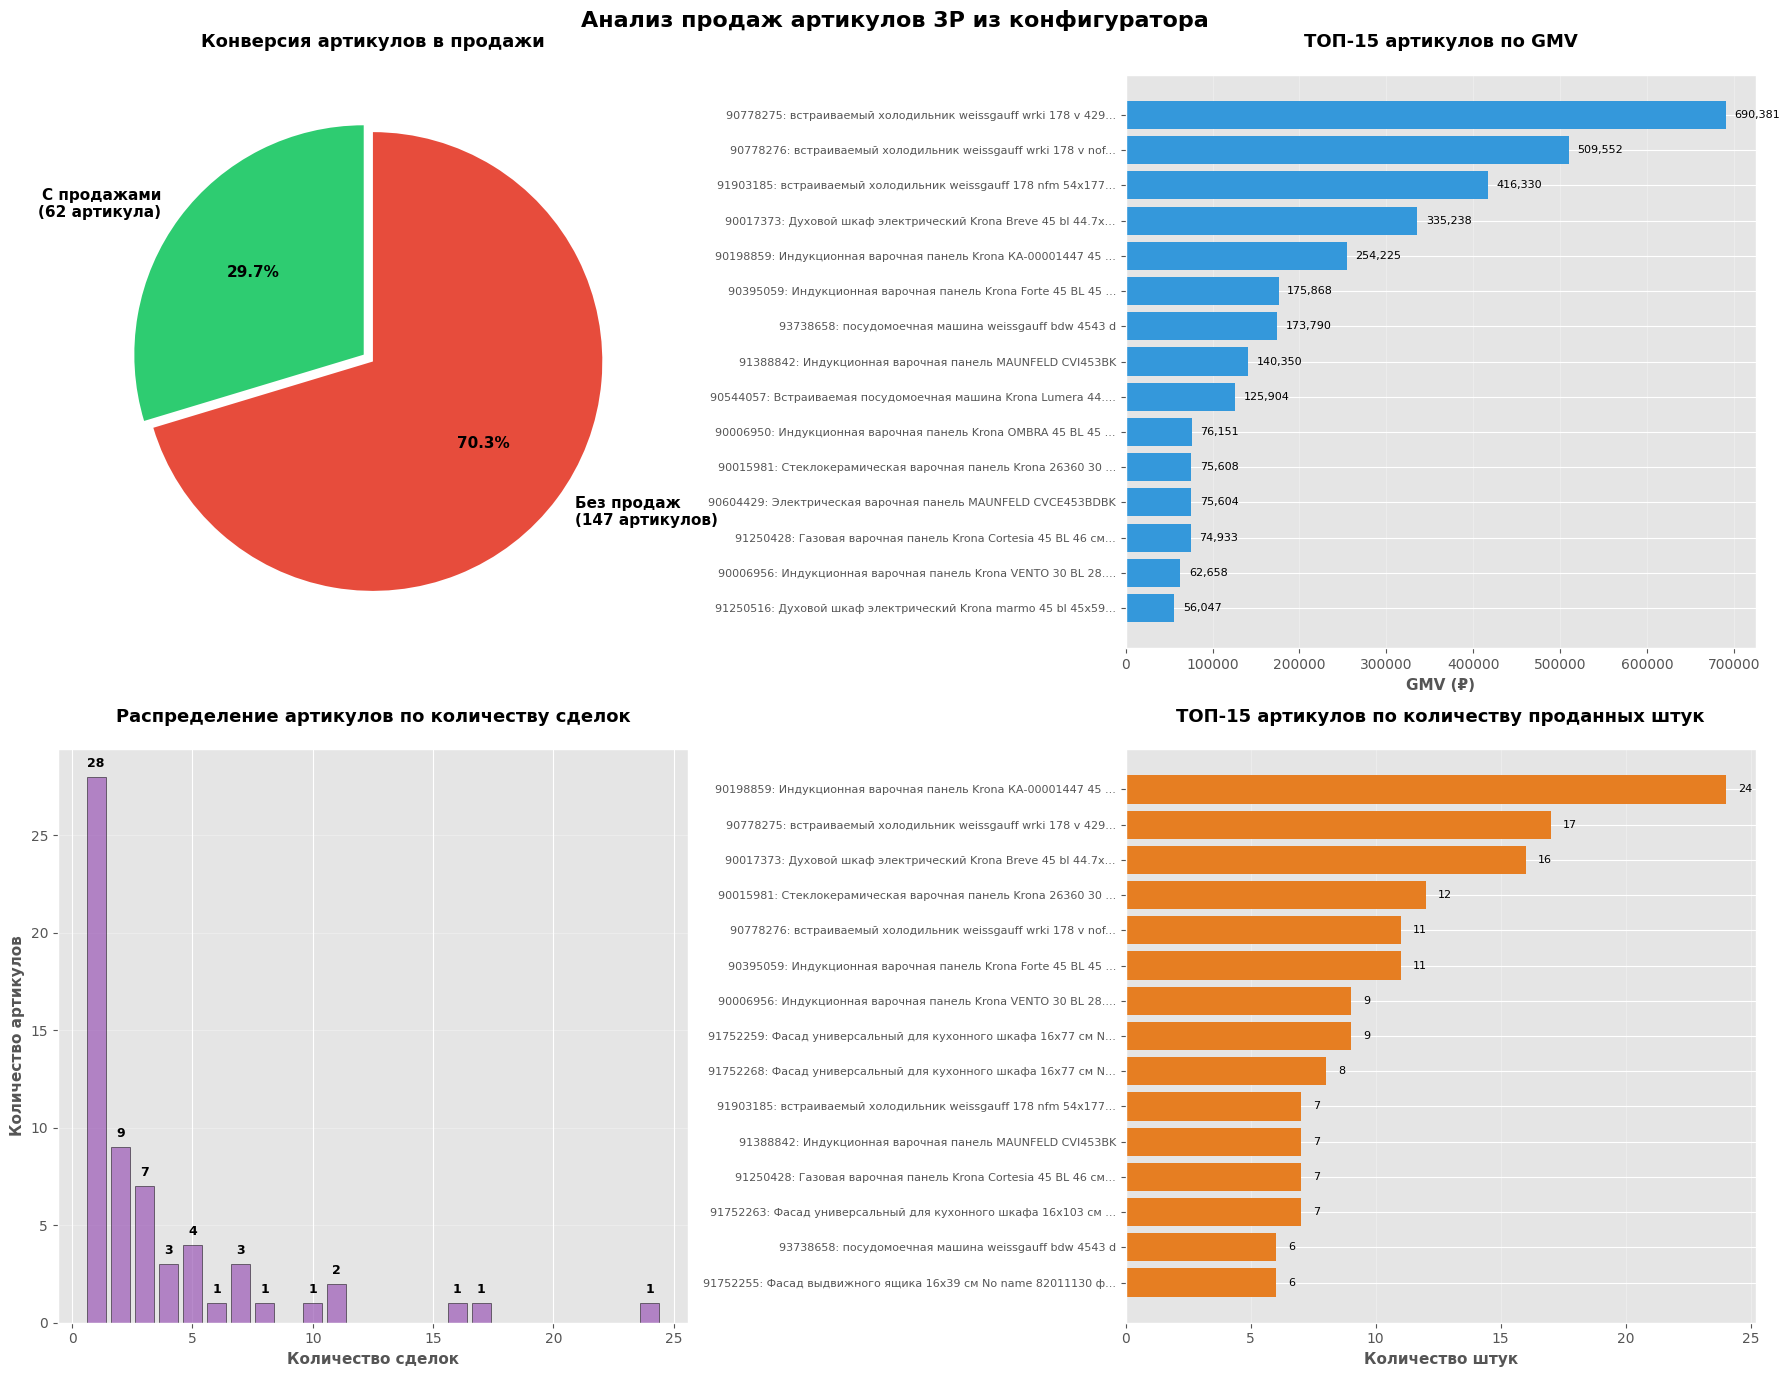


✅ Визуализация создана


In [12]:
# 📊 ВИЗУАЛИЗАЦИЯ ПРОДАЖ АРТИКУЛОВ 3Р (С РАСПРЕДЕЛЕНИЕМ ПО ЧАСТОТЕ ПРОДАЖ)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Анализ продаж артикулов 3Р из конфигуратора', fontsize=16, fontweight='bold')

# 1. Конверсия артикулов (круговая диаграмма)
ax1 = axes[0, 0]
labels = ['С продажами\n(62 артикула)', 'Без продаж\n(147 артикулов)']
sizes = [62, 147]
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Конверсия артикулов в продажи', fontsize=13, fontweight='bold', pad=20)

# 2. ТОП-15 артикулов по GMV (с наименованиями)
ax2 = axes[0, 1]
top15 = result_table[result_table['Суммарный_GMV'] > 0].head(15)
y_pos = np.arange(len(top15))

# Создаем красивые метки: артикул + сокращенное наименование
labels_gmv = []
for idx, row in top15.iterrows():
    name = row['Наименование']
    short_name = name[:50] + '...' if len(name) > 50 else name
    label = f"{row['Артикул']}: {short_name}"
    labels_gmv.append(label)

ax2.barh(y_pos, top15['Суммарный_GMV'], color='#3498db')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_gmv, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('GMV (₽)', fontsize=11, fontweight='bold')
ax2.set_title('ТОП-15 артикулов по GMV', fontsize=13, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(top15['Суммарный_GMV']):
    ax2.text(v + 10000, i, f'{v:,.0f}', va='center', fontsize=8)

# 3. Распределение артикулов по количеству сделок
ax3 = axes[1, 0]
deals_with_sales = result_table[result_table['Количество_сделок'] > 0]['Количество_сделок']

# Подсчитываем частоту
deals_distribution = deals_with_sales.value_counts().sort_index()

ax3.bar(deals_distribution.index, deals_distribution.values, color='#9b59b6', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Количество сделок', fontsize=11, fontweight='bold')
ax3.set_ylabel('Количество артикулов', fontsize=11, fontweight='bold')
ax3.set_title('Распределение артикулов по количеству сделок', fontsize=13, fontweight='bold', pad=20)
ax3.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in zip(deals_distribution.index, deals_distribution.values):
    ax3.text(i, v + 0.5, str(v), ha='center', fontsize=9, fontweight='bold')

# Статистика
print("\n📊 СТАТИСТИКА ПО ЧАСТОТЕ ПРОДАЖ:")
print("="*50)
for deals_count, artikuls_count in deals_distribution.items():
    percentage = (artikuls_count / len(deals_with_sales)) * 100
    print(f"Продано {deals_count} раз: {artikuls_count} артикулов ({percentage:.1f}%)")

# 4. ТОП-15 по количеству штук (с наименованиями)
ax4 = axes[1, 1]
top15_units = result_table[result_table['Количество_штук'] > 0].nlargest(15, 'Количество_штук')
y_pos = np.arange(len(top15_units))

labels_units = []
for idx, row in top15_units.iterrows():
    name = row['Наименование']
    short_name = name[:50] + '...' if len(name) > 50 else name
    label = f"{row['Артикул']}: {short_name}"
    labels_units.append(label)

ax4.barh(y_pos, top15_units['Количество_штук'], color='#e67e22')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(labels_units, fontsize=8)
ax4.invert_yaxis()
ax4.set_xlabel('Количество штук', fontsize=11, fontweight='bold')
ax4.set_title('ТОП-15 артикулов по количеству проданных штук', fontsize=13, fontweight='bold', pad=20)
ax4.grid(axis='x', alpha=0.3)

for i, v in enumerate(top15_units['Количество_штук']):
    ax4.text(v + 0.5, i, f'{int(v)}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Визуализация создана")

In [13]:
# 📊 АНАЛИЗ ПРОДАЖ АРТИКУЛОВ 3Р ПО ПОДОТДЕЛАМ

print("🔍 Связываем артикулы из конфигуратора с подотделами из сделок\n")

# 1. Фильтруем сделки - только артикулы из конфигуратора
artikuls_in_conf = df_conf_clean['Артикул'].unique()
df_sales_3p = df_deals_clean[df_deals_clean['Номер артикула'].isin(artikuls_in_conf)].copy()

print(f"✅ Отфильтровано сделок: {len(df_sales_3p)}")
print(f"   Уникальных артикулов 3Р в сделках: {df_sales_3p['Номер артикула'].nunique()}")

# 2. Преобразуем ТО в числовой формат (это и есть GMV)
df_sales_3p['GMV'] = pd.to_numeric(df_sales_3p['ТО'], errors='coerce')

print(f"   Строк с корректным GMV: {df_sales_3p['GMV'].notna().sum()}")

# 3. Группируем по подотделам
dept_summary = df_sales_3p.groupby('Подотдел').agg({
    'Шт.': 'sum',                    # Общее количество проданных штук
    'GMV': 'sum',                    # Общий GMV
    'Номер артикула': 'nunique',     # Уникальных артикулов 3Р
    'Номер сделки': 'nunique'        # Количество сделок
}).reset_index()

dept_summary.columns = ['Подотдел', 'Продано_штук', 'GMV', 'Уникальных_артикулов', 'Количество_сделок']

# 4. Сортируем по GMV
dept_summary = dept_summary.sort_values('GMV', ascending=False).reset_index(drop=True)

# 5. Добавляем процент от общего GMV
total_gmv = dept_summary['GMV'].sum()
dept_summary['Доля_GMV_%'] = (dept_summary['GMV'] / total_gmv * 100).round(2)

print(f"\n✅ ТАБЛИЦА ПО ПОДОТДЕЛАМ:")
print("="*100)
display(dept_summary)

print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"   • Подотделов с продажами артикулов 3Р: {len(dept_summary)}")
print(f"   • Общий GMV: {total_gmv:,.2f} ₽")
print(f"   • Всего продано штук: {dept_summary['Продано_штук'].sum():,.0f}")

🔍 Связываем артикулы из конфигуратора с подотделами из сделок

✅ Отфильтровано сделок: 225
   Уникальных артикулов 3Р в сделках: 62
   Строк с корректным GMV: 225

✅ ТАБЛИЦА ПО ПОДОТДЕЛАМ:


,Подотдел,Продано_штук,GMV,Уникальных_артикулов,Количество_сделок,Доля_GMV_%
0,1570 БЫТОВАЯ ТЕХНИКА,164,3450738,25,155,96.21
1,1520 ФАСАДЫ КУХОННЫЕ,109,135937,37,10,3.79



📊 ОБЩАЯ СТАТИСТИКА:
   • Подотделов с продажами артикулов 3Р: 2
   • Общий GMV: 3,586,675.00 ₽
   • Всего продано штук: 273


In [14]:
# 🔍 АНАЛИЗ ТОВАРОВ ОТДЕЛА КУХНИ, НЕ ЗАГРУЖЕННЫХ В КОНФИГУРАТОР

print("🔍 Поиск товаров отдела '15 Кухни', которых нет в конфигураторе\n")

# 1. Получаем список артикулов из конфигуратора
artikuls_in_conf = set(df_conf_clean['Артикул'].unique())
print(f"📌 Артикулов в конфигураторе: {len(artikuls_in_conf)}")

# 2. Фильтруем сделки: отдел "15 Кухни" + НЕТ в конфигураторе
df_kitchen = df_deals_clean[
    (df_deals_clean['Отдел'].str.contains('15', na=False)) &
    (~df_deals_clean['Номер артикула'].isin(artikuls_in_conf))
].copy()

print(f"✅ Найдено сделок с товарами кухни (не в конфигураторе): {len(df_kitchen)}")
print(f"   Уникальных артикулов: {df_kitchen['Номер артикула'].nunique()}")

# 3. Преобразуем GMV
df_kitchen['GMV'] = pd.to_numeric(df_kitchen['ТО'], errors='coerce')

# 4. Группируем по артикулам
kitchen_summary = df_kitchen.groupby(['Номер артикула', 'Артикул']).agg({
    'Шт.': 'sum',                    # Количество проданных штук
    'GMV': 'sum',                    # Суммарный GMV
    'Номер сделки': 'nunique',       # Количество сделок
    'Подотдел': 'first'              # Подотдел (для справки)
}).reset_index()

kitchen_summary.columns = ['Номер_артикула', 'Наименование', 'Продано_штук', 'GMV', 'Количество_сделок', 'Подотдел']

# 5. Сортируем по GMV (самые продаваемые)
kitchen_summary = kitchen_summary.sort_values('GMV', ascending=False).reset_index(drop=True)

# 6. Добавляем среднюю цену
kitchen_summary['Средняя_цена_за_шт'] = (kitchen_summary['GMV'] / kitchen_summary['Продано_штук']).round(2)

print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"   • Всего артикулов кухни (не в конфигураторе): {len(kitchen_summary)}")
print(f"   • Общий GMV этих товаров: {kitchen_summary['GMV'].sum():,.2f} ₽")
print(f"   • Всего продано штук: {kitchen_summary['Продано_штук'].sum():,.0f}")

print(f"\n📈 ТОП-20 самых продаваемых товаров кухни (по GMV), которых НЕТ в конфигураторе:")
print("="*120)
display(kitchen_summary.head(20))

# 7. Статистика по подотделам
print(f"\n📊 Распределение по подотделам:")
subdept_stats = kitchen_summary.groupby('Подотдел').agg({
    'Номер_артикула': 'count',
    'GMV': 'sum',
    'Продано_штук': 'sum'
}).sort_values('GMV', ascending=False)
subdept_stats.columns = ['Количество_артикулов', 'GMV', 'Продано_штук']
display(subdept_stats)

🔍 Поиск товаров отдела '15 Кухни', которых нет в конфигураторе

📌 Артикулов в конфигураторе: 209
✅ Найдено сделок с товарами кухни (не в конфигураторе): 4090
   Уникальных артикулов: 2495

📊 ОБЩАЯ СТАТИСТИКА:
   • Всего артикулов кухни (не в конфигураторе): 2495
   • Общий GMV этих товаров: 79,403,526.00 ₽
   • Всего продано штук: 4,432

📈 ТОП-20 самых продаваемых товаров кухни (по GMV), которых НЕТ в конфигураторе:


,Номер_артикула,Наименование,Продано_штук,GMV,Количество_сделок,Подотдел,Средняя_цена_за_шт
0,92008820,встраиваемый холодильник indesit ibh 20 54x193...,53,3300947,51,1570 БЫТОВАЯ ТЕХНИКА,62282.02
1,92006524,встраиваемый холодильник haier hur100ru 59.5x8...,18,809982,17,1570 БЫТОВАЯ ТЕХНИКА,44999.00
2,92008822,встраиваемый холодильник indesit ibd 18 54x177...,16,773304,15,1570 БЫТОВАЯ ТЕХНИКА,48331.50
3,91260564,посудомоечная машина встраиваемая krona garda ...,36,764079,35,1570 БЫТОВАЯ ТЕХНИКА,21224.42
4,91029541,встраиваемый холодильник weissgauff wrki 178 t...,12,502398,12,1570 БЫТОВАЯ ТЕХНИКА,41866.50
5,92313703,встраиваемая микроволновая печь weissgauff hmt...,29,502260,29,1570 БЫТОВАЯ ТЕХНИКА,17319.31
6,92015225,встраиваемый холодильник maunfeld mbf88swgr 59...,12,482230,11,1570 БЫТОВАЯ ТЕХНИКА,40185.83
7,91887664,газовый духовой шкаф weissgauff wgo 706 d blac...,13,457540,13,1570 БЫТОВАЯ ТЕХНИКА,35195.38
8,92330514,встраиваемый холодильник midea mdre414fge01 54...,5,424950,5,1570 БЫТОВАЯ ТЕХНИКА,84990.00
9,92308572,встраиваемый холодильник hotpoint hbh 18 белый...,7,417984,5,1570 БЫТОВАЯ ТЕХНИКА,59712.00



📊 Распределение по подотделам:


,Количество_артикулов,GMV,Продано_штук
Подотдел,,,
1570 БЫТОВАЯ ТЕХНИКА,1365,64830134,2605
1550 МОЙКИ,300,4159259,450
1505 Модульные Кухни,293,3208857,403
1530 СТОЛЕШНИЦЫ,181,2962430,315
1560 СМЕСИТЕЛИ,213,2335928,322
1535 СТОЛЫ,47,979806,83
1545 СТУЛЬЯ И ТАБУРЕТЫ,41,622055,147
1540 АКСЕССУАРЫ КУХОННЫЕ,35,167549,38
1520 ФАСАДЫ КУХОННЫЕ,18,130309,67


🔍 Группировка товаров кухни по подотделам

✅ ТАБЛИЦА: Товары отдела Кухни по подотделам (НЕ в конфигураторе)


,Подотдел,Продано_штук,GMV,Уникальных_артикулов,Количество_сделок,Доля_GMV_%
0,1570 БЫТОВАЯ ТЕХНИКА,2605,64830134,1365,1511,81.65
1,1550 МОЙКИ,450,4159259,300,438,5.24
2,1505 Модульные Кухни,403,3208857,293,68,4.04
3,1530 СТОЛЕШНИЦЫ,315,2962430,181,147,3.73
4,1560 СМЕСИТЕЛИ,322,2335928,213,318,2.94
5,1535 СТОЛЫ,83,979806,47,59,1.23
6,1545 СТУЛЬЯ И ТАБУРЕТЫ,147,622055,41,40,0.78
7,1540 АКСЕССУАРЫ КУХОННЫЕ,38,167549,35,28,0.21
8,1520 ФАСАДЫ КУХОННЫЕ,67,130309,18,5,0.16
9,1599 ПРО,2,7199,2,2,0.01



📊 ИТОГОВАЯ СТАТИСТИКА:
   • Подотделов с товарами кухни (не в конфигураторе): 10
   • Общий GMV: 79,403,526.00 ₽
   • Всего продано штук: 4,432
   • ТОП-3 подотдела по GMV:
      1. 1570 БЫТОВАЯ ТЕХНИКА: 64,830,134.00 ₽ (81.7%)
      2. 1550 МОЙКИ: 4,159,259.00 ₽ (5.2%)
      3. 1505 Модульные Кухни: 3,208,857.00 ₽ (4.0%)


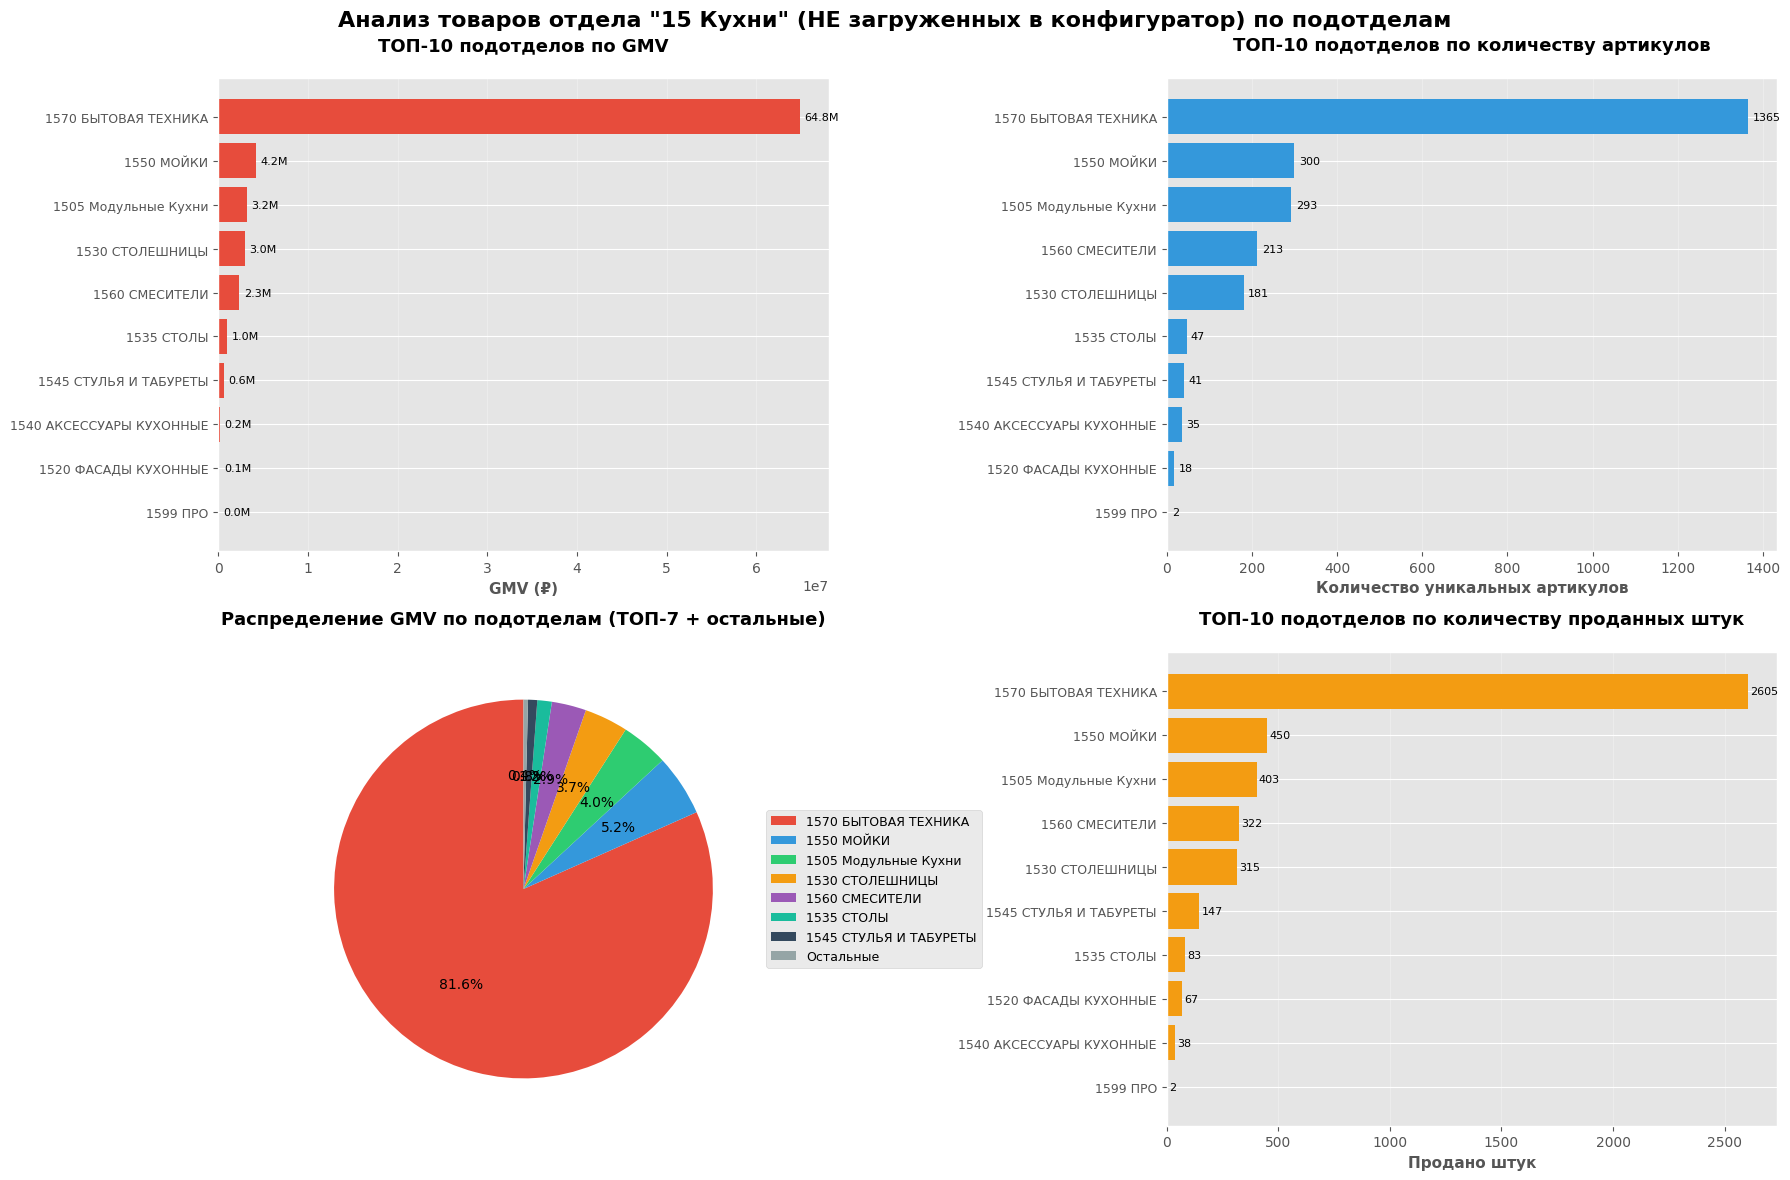


✅ Визуализация по подотделам создана


In [15]:
# 📊 АНАЛИЗ ПО ПОДОТДЕЛАМ: товары кухни, которых НЕТ в конфигураторе

print("🔍 Группировка товаров кухни по подотделам\n")

# 1. Группируем по подотделам
kitchen_by_subdept = df_kitchen.groupby('Подотдел').agg({
    'Шт.': 'sum',                    # Продано штук
    'GMV': 'sum',                    # Суммарный GMV
    'Номер артикула': 'nunique',     # Уникальных артикулов
    'Номер сделки': 'nunique'        # Количество сделок
}).reset_index()

kitchen_by_subdept.columns = ['Подотдел', 'Продано_штук', 'GMV', 'Уникальных_артикулов', 'Количество_сделок']

# 2. Добавляем долю GMV
total_gmv_kitchen = kitchen_by_subdept['GMV'].sum()
kitchen_by_subdept['Доля_GMV_%'] = (kitchen_by_subdept['GMV'] / total_gmv_kitchen * 100).round(2)

# 3. Сортируем по GMV
kitchen_by_subdept = kitchen_by_subdept.sort_values('GMV', ascending=False).reset_index(drop=True)

print("✅ ТАБЛИЦА: Товары отдела Кухни по подотделам (НЕ в конфигураторе)")
print("="*120)
display(kitchen_by_subdept)

print(f"\n📊 ИТОГОВАЯ СТАТИСТИКА:")
print(f"   • Подотделов с товарами кухни (не в конфигураторе): {len(kitchen_by_subdept)}")
print(f"   • Общий GMV: {total_gmv_kitchen:,.2f} ₽")
print(f"   • Всего продано штук: {kitchen_by_subdept['Продано_штук'].sum():,.0f}")
print(f"   • ТОП-3 подотдела по GMV:")
for idx, row in kitchen_by_subdept.head(3).iterrows():
    print(f"      {idx+1}. {row['Подотдел']}: {row['GMV']:,.2f} ₽ ({row['Доля_GMV_%']:.1f}%)")

# 📊 ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Анализ товаров отдела "15 Кухни" (НЕ загруженных в конфигуратор) по подотделам',
             fontsize=16, fontweight='bold')

# 1. ТОП-10 подотделов по GMV
ax1 = axes[0, 0]
top10_gmv = kitchen_by_subdept.head(10)
y_pos = np.arange(len(top10_gmv))

ax1.barh(y_pos, top10_gmv['GMV'], color='#e74c3c')
ax1.set_yticks(y_pos)
labels_subdept = [dept[:45] + '...' if len(str(dept)) > 45 else dept for dept in top10_gmv['Подотдел']]
ax1.set_yticklabels(labels_subdept, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('GMV (₽)', fontsize=11, fontweight='bold')
ax1.set_title('ТОП-10 подотделов по GMV', fontsize=13, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

for i, v in enumerate(top10_gmv['GMV']):
    ax1.text(v + 500000, i, f'{v/1e6:.1f}M', va='center', fontsize=8)

# 2. ТОП-10 подотделов по количеству артикулов
ax2 = axes[0, 1]
top10_art = kitchen_by_subdept.nlargest(10, 'Уникальных_артикулов')
y_pos = np.arange(len(top10_art))

ax2.barh(y_pos, top10_art['Уникальных_артикулов'], color='#3498db')
ax2.set_yticks(y_pos)
labels_art = [dept[:45] + '...' if len(str(dept)) > 45 else dept for dept in top10_art['Подотдел']]
ax2.set_yticklabels(labels_art, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Количество уникальных артикулов', fontsize=11, fontweight='bold')
ax2.set_title('ТОП-10 подотделов по количеству артикулов', fontsize=13, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(top10_art['Уникальных_артикулов']):
    ax2.text(v + 10, i, f'{int(v)}', va='center', fontsize=8)

# 3. Доля GMV по подотделам (ТОП-7 + остальные)
ax3 = axes[1, 0]
top7 = kitchen_by_subdept.head(7)
others_gmv = kitchen_by_subdept.iloc[7:]['GMV'].sum()

labels_pie = list(top7['Подотдел'])
sizes_pie = list(top7['GMV'])

if others_gmv > 0:
    labels_pie.append('Остальные')
    sizes_pie.append(others_gmv)

colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e', '#95a5a6']

ax3.pie(sizes_pie, labels=None, colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax3.set_title('Распределение GMV по подотделам (ТОП-7 + остальные)', fontsize=13, fontweight='bold', pad=20)

legend_labels = [f"{str(label)[:30]}..." if len(str(label)) > 30 else label for label in labels_pie]
ax3.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

# 4. ТОП-10 по проданным штукам
ax4 = axes[1, 1]
top10_units = kitchen_by_subdept.nlargest(10, 'Продано_штук')
y_pos = np.arange(len(top10_units))

ax4.barh(y_pos, top10_units['Продано_штук'], color='#f39c12')
ax4.set_yticks(y_pos)
labels_units = [dept[:45] + '...' if len(str(dept)) > 45 else dept for dept in top10_units['Подотдел']]
ax4.set_yticklabels(labels_units, fontsize=9)
ax4.invert_yaxis()
ax4.set_xlabel('Продано штук', fontsize=11, fontweight='bold')
ax4.set_title('ТОП-10 подотделов по количеству проданных штук', fontsize=13, fontweight='bold', pad=20)
ax4.grid(axis='x', alpha=0.3)

for i, v in enumerate(top10_units['Продано_штук']):
    ax4.text(v + 10, i, f'{int(v)}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Визуализация по подотделам создана")

In [16]:
# 📊 АНАЛИЗ ТОП-15 АРТИКУЛОВ ПО КЛЮЧЕВЫМ КАТЕГОРИЯМ КУХНИ

print("🔍 Поиск ТОП-15 артикулов по категориям (НЕ в конфигураторе)\n")
print("="*100)

# Определяем категории по ключевым словам в подотделах
categories = {
    'Бытовая техника': ['техника', 'холодильник', 'плита', 'духовка', 'духовой', 'варочная', 'посудомоечная', 'вытяжка', 'микроволновая'],
    'Мойки': ['мойка', 'мойки'],
    'Смесители': ['смеситель', 'смесители'],
    'Столешницы': ['столешница', 'столешницы']
}

# Словарь для хранения результатов
top_by_category = {}

# Проходим по каждой категории
for category_name, keywords in categories.items():
    print(f"\n{'='*100}")
    print(f"📂 КАТЕГОРИЯ: {category_name}")
    print(f"{'='*100}")

    # Фильтруем по ключевым словам в подотделе (регистронезависимо)
    mask = df_kitchen['Подотдел'].str.lower().str.contains('|'.join(keywords), na=False, case=False)
    df_category = df_kitchen[mask].copy()

    if len(df_category) == 0:
        print(f"   ⚠️ Товары не найдены в категории '{category_name}'")
        continue

    # Группируем по артикулам
    category_summary = df_category.groupby(['Номер артикула', 'Артикул']).agg({
        'Шт.': 'sum',
        'GMV': 'sum',
        'Номер сделки': 'nunique',
        'Подотдел': 'first'
    }).reset_index()

    category_summary.columns = ['Номер_артикула', 'Наименование', 'Продано_штук', 'GMV', 'Количество_сделок', 'Подотдел']

    # Добавляем среднюю цену
    category_summary['Средняя_цена_за_шт'] = (category_summary['GMV'] / category_summary['Продано_штук']).round(2)

    # Сортируем по GMV
    category_summary = category_summary.sort_values('GMV', ascending=False).reset_index(drop=True)

    # Берем ТОП-15
    top15 = category_summary.head(15)

    # Сохраняем в словарь
    top_by_category[category_name] = top15

    # Выводим статистику
    print(f"\n📊 Статистика по категории '{category_name}':")
    print(f"   • Всего артикулов: {len(category_summary)}")
    print(f"   • Общий GMV категории: {category_summary['GMV'].sum():,.2f} ₽")
    print(f"   • Продано штук: {category_summary['Продано_штук'].sum():,.0f}")
    print(f"   • Количество сделок: {category_summary['Количество_сделок'].sum():,.0f}")

    print(f"\n📈 ТОП-15 артикулов по GMV:")
    display(top15[['Номер_артикула', 'Наименование', 'Продано_штук', 'GMV', 'Количество_сделок', 'Средняя_цена_за_шт', 'Подотдел']])

print("\n" + "="*100)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("="*100)

# Итоговая сводка
print(f"\n📊 ИТОГОВАЯ СВОДКА ПО КАТЕГОРИЯМ:\n")
for cat_name, df_cat in top_by_category.items():
    total_gmv = df_cat['GMV'].sum()
    total_units = df_cat['Продано_штук'].sum()
    print(f"   • {cat_name}: {len(df_cat)} артикулов, GMV: {total_gmv:,.2f} ₽, Штук: {int(total_units)}")

🔍 Поиск ТОП-15 артикулов по категориям (НЕ в конфигураторе)


📂 КАТЕГОРИЯ: Бытовая техника

📊 Статистика по категории 'Бытовая техника':
   • Всего артикулов: 1365
   • Общий GMV категории: 64,830,134.00 ₽
   • Продано штук: 2,605
   • Количество сделок: 2,560

📈 ТОП-15 артикулов по GMV:


,Номер_артикула,Наименование,Продано_штук,GMV,Количество_сделок,Средняя_цена_за_шт,Подотдел
0,92008820,встраиваемый холодильник indesit ibh 20 54x193...,53,3300947,51,62282.02,1570 БЫТОВАЯ ТЕХНИКА
1,92006524,встраиваемый холодильник haier hur100ru 59.5x8...,18,809982,17,44999.00,1570 БЫТОВАЯ ТЕХНИКА
2,92008822,встраиваемый холодильник indesit ibd 18 54x177...,16,773304,15,48331.50,1570 БЫТОВАЯ ТЕХНИКА
3,91260564,посудомоечная машина встраиваемая krona garda ...,36,764079,35,21224.42,1570 БЫТОВАЯ ТЕХНИКА
4,91029541,встраиваемый холодильник weissgauff wrki 178 t...,12,502398,12,41866.50,1570 БЫТОВАЯ ТЕХНИКА
5,92313703,встраиваемая микроволновая печь weissgauff hmt...,29,502260,29,17319.31,1570 БЫТОВАЯ ТЕХНИКА
6,92015225,встраиваемый холодильник maunfeld mbf88swgr 59...,12,482230,11,40185.83,1570 БЫТОВАЯ ТЕХНИКА
7,91887664,газовый духовой шкаф weissgauff wgo 706 d blac...,13,457540,13,35195.38,1570 БЫТОВАЯ ТЕХНИКА
8,92330514,встраиваемый холодильник midea mdre414fge01 54...,5,424950,5,84990.00,1570 БЫТОВАЯ ТЕХНИКА
9,92308572,встраиваемый холодильник hotpoint hbh 18 белый...,7,417984,5,59712.00,1570 БЫТОВАЯ ТЕХНИКА



📂 КАТЕГОРИЯ: Мойки

📊 Статистика по категории 'Мойки':
   • Всего артикулов: 300
   • Общий GMV категории: 4,159,259.00 ₽
   • Продано штук: 450
   • Количество сделок: 447

📈 ТОП-15 артикулов по GMV:


,Номер_артикула,Наименование,Продано_штук,GMV,Количество_сделок,Средняя_цена_за_шт,Подотдел
0,91930769,мойка для кухни врезная glyph gl35050 50x50 см...,45,205297,45,4562.16,1550 МОЙКИ
1,98258148,мойка для кухни нержавеющая врезная 50x50 wise...,14,121281,14,8662.93,1550 МОЙКИ
2,90769591,мойка для кухни нержавеющая врезная с крылом 7...,5,61920,5,12384.00,1550 МОЙКИ
3,98299242,кухонная мойка omoikiri sagami 79-in 79x50см и...,3,48564,3,16188.00,1550 МОЙКИ
4,91266681,мойка для кухни из искусственного камня gerhan...,5,45894,5,9178.80,1550 МОЙКИ
5,91930775,мойка для кухни врезная с дозатором glyph gl35...,7,43732,7,6247.43,1550 МОЙКИ
6,91930782,мойка для кухни врезная с дозатором glyph gl35...,5,40873,5,8174.60,1550 МОЙКИ
7,98299266,кухонная мойка omoikiri daisen 60-pa 60x51см и...,2,39776,2,19888.00,1550 МОЙКИ
8,91266680,мойка для кухни из искусственного камня gerhan...,4,38293,4,9573.25,1550 МОЙКИ
9,91266672,мойка для кухни из искусственного камня gerhan...,4,36392,3,9098.00,1550 МОЙКИ



📂 КАТЕГОРИЯ: Смесители

📊 Статистика по категории 'Смесители':
   • Всего артикулов: 213
   • Общий GMV категории: 2,335,928.00 ₽
   • Продано штук: 322
   • Количество сделок: 321

📈 ТОП-15 артикулов по GMV:


,Номер_артикула,Наименование,Продано_штук,GMV,Количество_сделок,Средняя_цена_за_шт,Подотдел
0,91967994,смеситель для кухни esko line el_k112 выдвижно...,12,94320,12,7860.00,1560 СМЕСИТЕЛИ
1,92212613,смеситель для кухни maretti eng31rgf13 гибкий ...,9,75150,9,8350.00,1560 СМЕСИТЕЛИ
2,91996260,смеситель для кухни maretti project black с по...,11,70400,11,6400.00,1560 СМЕСИТЕЛИ
3,91967995,смеситель для кухни esko line el_k108 flex b с...,9,55460,9,6162.22,1560 СМЕСИТЕЛИ
4,91700863,смеситель для кухни smz 81smzfau поворотный из...,8,54400,8,6800.00,1560 СМЕСИТЕЛИ
5,92425289,смеситель для кухни granula 8170 черный 30.5 с...,2,38800,2,19400.00,1560 СМЕСИТЕЛИ
6,91000900,смеситель для кухни однорычажный paulmark la21...,1,32900,1,32900.00,1560 СМЕСИТЕЛИ
7,91582263,смеситель для кухни однорычажный shevanik s468...,5,32238,5,6447.60,1560 СМЕСИТЕЛИ
8,91577447,смеситель для кухни однорычажный maretti proje...,4,31861,4,7965.25,1560 СМЕСИТЕЛИ
9,92349666,смеситель для кухни paulmark se213222-ni выдви...,1,31000,1,31000.00,1560 СМЕСИТЕЛИ



📂 КАТЕГОРИЯ: Столешницы

📊 Статистика по категории 'Столешницы':
   • Всего артикулов: 181
   • Общий GMV категории: 2,962,430.00 ₽
   • Продано штук: 315
   • Количество сделок: 222

📈 ТОП-15 артикулов по GMV:


,Номер_артикула,Наименование,Продано_штук,GMV,Количество_сделок,Средняя_цена_за_шт,Подотдел
0,92061080,кухонная столешница slotex 240x60x1.2 см hpl-п...,15,297902,9,19860.13,1530 СТОЛЕШНИЦЫ
1,92061082,кухонная столешница slotex 240x60x1.2 см hpl-п...,8,184060,5,23007.50,1530 СТОЛЕШНИЦЫ
2,92484140,кухонная столешница slotex 240x60x2 см hpl-пла...,3,106014,2,35338.00,1530 СТОЛЕШНИЦЫ
3,92294094,комплект столешница и стеновая панель для кухн...,3,95415,3,31805.00,1530 СТОЛЕШНИЦЫ
4,92317670,кухонная столешница slotex 240x60x1.2 см hpl-п...,4,91094,2,22773.50,1530 СТОЛЕШНИЦЫ
5,92302339,кухонная столешница slotex 240x60x1.2 см hpl-п...,3,73860,2,24620.00,1530 СТОЛЕШНИЦЫ
6,91333028,кухонная столешница скиф диамант 240x60x3.8 см...,6,53940,3,8990.00,1530 СТОЛЕШНИЦЫ
7,92311515,кухонная столешница slotex 240x60x1.2 см hpl-п...,2,49240,1,24620.00,1530 СТОЛЕШНИЦЫ
8,92302334,кухонная столешница slotex 240x60x1.2 см hpl-п...,2,49240,2,24620.00,1530 СТОЛЕШНИЦЫ
9,92302338,кухонная столешница slotex 240x60x1.2 см hpl-п...,2,49240,1,24620.00,1530 СТОЛЕШНИЦЫ



✅ АНАЛИЗ ЗАВЕРШЕН

📊 ИТОГОВАЯ СВОДКА ПО КАТЕГОРИЯМ:

   • Бытовая техника: 15 артикулов, GMV: 10,221,009.00 ₽, Штук: 266
   • Мойки: 15 артикулов, GMV: 847,379.00 ₽, Штук: 107
   • Смесители: 15 артикулов, GMV: 647,361.00 ₽, Штук: 74
   • Столешницы: 15 артикулов, GMV: 1,268,394.00 ₽, Штук: 61
